In [1]:
import os
from pyhere import here

os.chdir(here())

In [2]:
import geopandas as gpd
import pandas as pd
import elapid as ela

In [3]:
%load_ext autoreload
%autoreload 2

import json

import elapid as ela
import geopandas as gpd
import rioxarray as rxr

from sklearn.metrics import roc_auc_score
from folium import Map, GeoJson, CircleMarker
from matplotlib import pyplot as plt


from sdm.models.utils.utils import prepare_occurrence_data
from sdm.models.maxent.maxent_model import evaluate_and_train_maxent_model
from sdm.raster.io import load_environmental_variables
from sdm.raster.utils import generate_point_grid
from sdm.occurrence.species_data import latin_name, activity_type, genus
from sdm.utils.io import load_config
from sdm.utils.io import load_boundary, load_model_config

from pathlib import Path

In [4]:
from sdm.utils.io import load_project_config

config = load_project_config()

boundary = gpd.read_file(config.paths.boundary)


<Axes: >

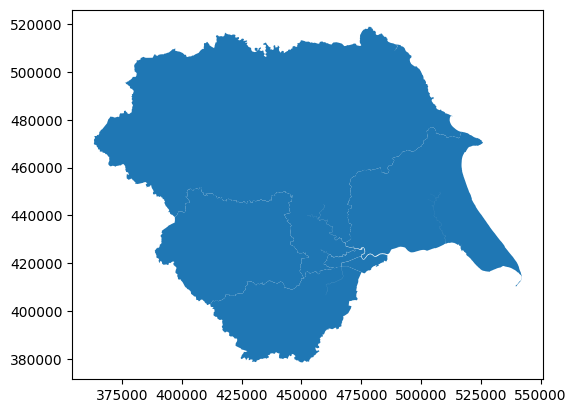

In [5]:
boundary.plot()

In [6]:
bats = gpd.read_file(config.paths.occurence_data)
bats = bats.to_crs(27700)

bats.head()

,unique_id,latin_name,activity_type,date,x,y,accuracy,source_info,geometry
0,NYBG_2,Nyctalus noctula,In flight,1996-06-10,465350.0,457750.0,100,"{ ""source"": ""NYBG"", ""source_file"": ""All Yorksh...",POINT (465350 457750)
1,NYBG_9,Nyctalus noctula,In flight,1997-04-09,429550.0,477250.0,100,"{ ""source"": ""NYBG"", ""source_file"": ""All Yorksh...",POINT (429550 477250)
2,NYBG_11,Nyctalus noctula,In flight,1997-06-09,446450.0,435450.0,100,"{ ""source"": ""NYBG"", ""source_file"": ""All Yorksh...",POINT (446450 435450)
3,NYBG_14,Nyctalus noctula,In flight,1997-06-24,439650.0,467050.0,100,"{ ""source"": ""NYBG"", ""source_file"": ""All Yorksh...",POINT (439650 467050)
4,NYBG_37,Nyctalus noctula,In flight,1997-10-17,429550.0,477250.0,100,"{ ""source"": ""NYBG"", ""source_file"": ""All Yorksh...",POINT (429550 477250)


In [7]:
# get foraging pipistrelles

foraging = bats[
    (bats.latin_name == "Pipistrellus pipistrellus")
    & (bats.activity_type == "Foraging")
]
foraging = foraging[foraging.intersects(boundary.geometry.union_all())]

In [8]:
evs, ev_path = load_environmental_variables(config.paths.ev_tiff)


evs

<xarray.Dataset> Size: 918MB
Dimensions:                                   (x: 1930, y: 1544)
Coordinates:
  * x                                         (x) float64 15kB 3.562e+05 ... ...
  * y                                         (y) float64 12kB 3.716e+05 ... ...
    spatial_ref                               int64 8B 0
Data variables: (12/77)
    climate_stats_temp_ann_var                (y, x) float32 12MB ...
    climate_bioclim_bio_4                     (y, x) float32 12MB ...
    climate_bioclim_bio_7                     (y, x) float32 12MB ...
    climate_bioclim_bio_2                     (y, x) float32 12MB ...
    climate_stats_prec_ann_var                (y, x) float32 12MB ...
    terrain_dtm                               (y, x) float32 12MB ...
    ...                                        ...
    vom_vegetation_height_mean_1500m          (y, x) float32 12MB ...
    ceh_landcover_suburban_1500m              (y, x) float32 12MB ...
    os_cover_water_1500m                      (y, x) float32 12MB ...
    ceh_landcover_coniferous_woodland_1500m   (y, x) float32 12MB ...
    ceh_landcover_urban_1500m                 (y, x) float32 12MB ...
    ceh_landcover_improved_grassland_1500m    (y, x) float32 12MB ...
Attributes:
    AREA_OR_POINT:  Area

In [9]:
evs.data_vars

Data variables:
    climate_stats_temp_ann_var                (y, x) float32 12MB ...
    climate_bioclim_bio_4                     (y, x) float32 12MB ...
    climate_bioclim_bio_7                     (y, x) float32 12MB ...
    climate_bioclim_bio_2                     (y, x) float32 12MB ...
    climate_stats_prec_ann_var                (y, x) float32 12MB ...
    terrain_dtm                               (y, x) float32 12MB ...
    climate_stats_prec_ann_avg                (y, x) float32 12MB ...
    climate_stats_temp_ann_avg                (y, x) float32 12MB ...
    climate_stats_temp_mat_avg                (y, x) float32 12MB ...
    ceh_landcover_wetland                     (y, x) float32 12MB ...
    os_distance_distance_to_buildings         (y, x) float32 12MB ...
    os_distance_distance_to_minor_roads       (y, x) float32 12MB ...
    climate_bioclim_bio_9                     (y, x) float32 12MB ...
    bgs_coast_distance_to_coast               (y, x) float32 12MB ...
    

In [10]:
evs = evs.rio.clip(boundary.geometry)

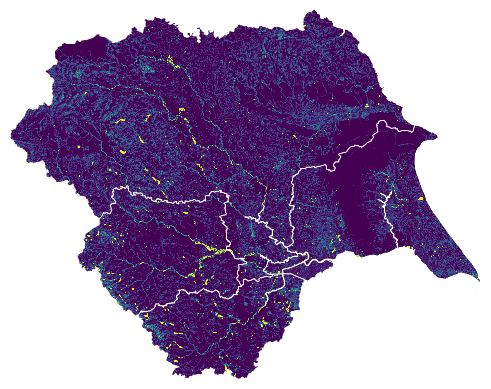

In [11]:
import xarray as xr
import numpy as np


def plot_variable(
    dataset: xr.Dataset, variable: str, cmap: str = "viridis", vmin=None, vmax=None
):
    fig, ax = plt.subplots(1, 1)
    band = dataset[variable]
    if vmin is None:
        vmin = band.min()
    if vmax is None:
        vmax = band.max()
    mask = band.isnull()
    band = band.where(band > vmin, vmin)
    band = band.where(band < vmax, vmax)
    band = band.where(~mask, np.nan)
    band.plot(ax=ax, cmap=cmap, add_colorbar=False)
    boundary.boundary.plot(
        ax=ax,
        color="white",
        linewidth=0.5,
    )
    ax.axis("off")
    ax.set_title("")
    plt.show()


plot_variable(evs, "os_cover_water", "viridis", vmin=0, vmax=25)

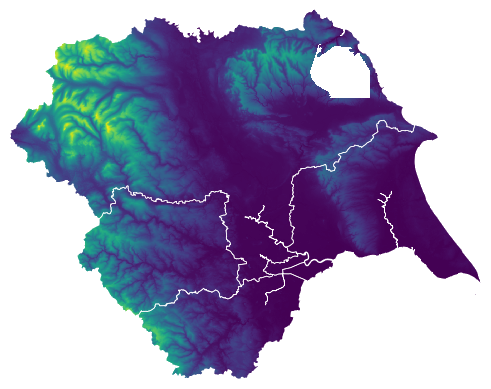

In [12]:
plot_variable(evs, "terrain_dtm", "viridis", vmin=0)

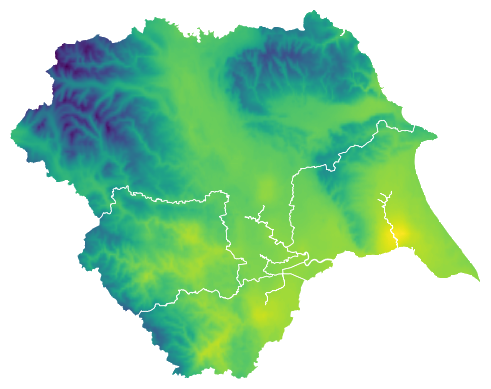

In [13]:
plot_variable(
    evs,
    "climate_stats_temp_ann_avg",
    "viridis",
)

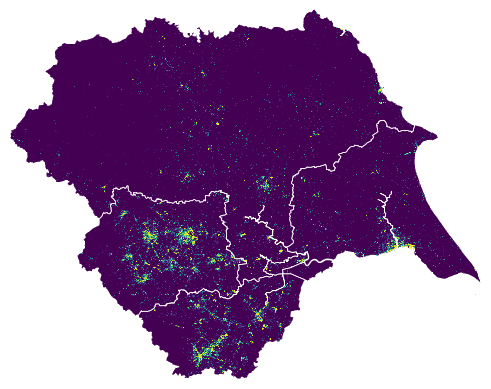

In [14]:
plot_variable(evs, "ceh_landcover_urban", "viridis")

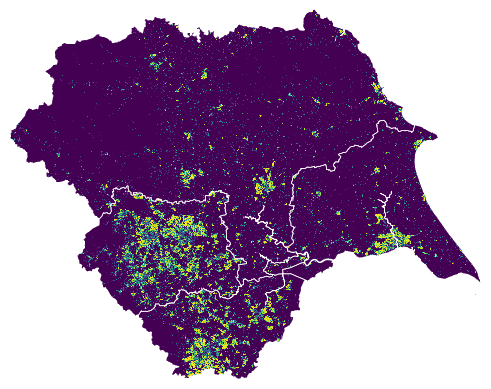

In [15]:
plot_variable(evs, "ceh_landcover_suburban", "viridis")

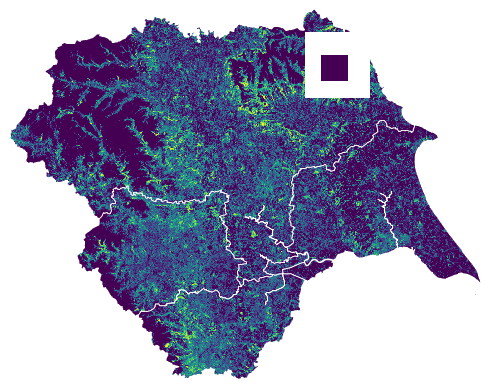

In [16]:
plot_variable(evs, "vom_vegetation_height_max", "viridis", vmin=0, vmax=30)

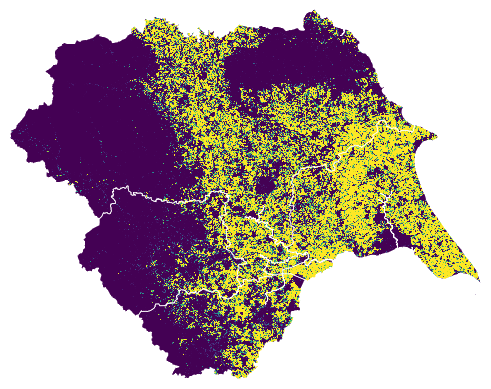

In [17]:
plot_variable(evs, "ceh_landcover_arable", "viridis")

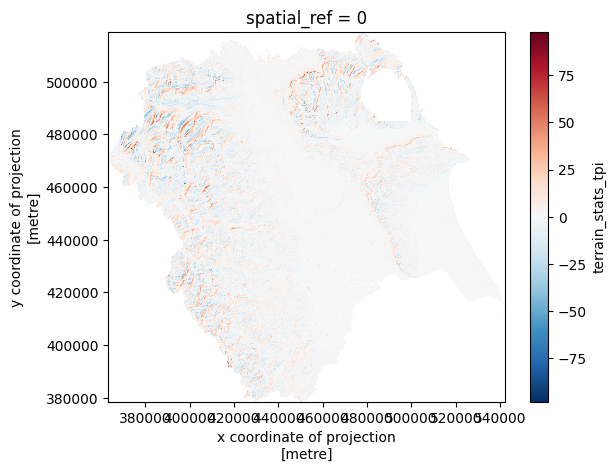

In [18]:
evs.terrain_stats_tpi.plot()

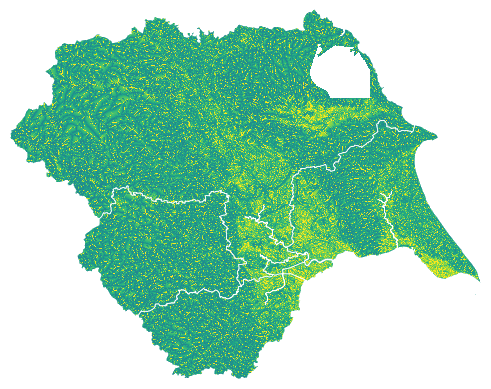

In [19]:
plot_variable(evs, "terrain_stats_twi", "viridis", vmin=-5, vmax=5)

In [20]:
import pandas as pd

trial_data = pd.read_csv("data/sdm_tuning/Myotis_daubentonii_In_flight/trial_data.csv")
trial_data.head()

trial_data = trial_data[trial_data.trial_number < 200]

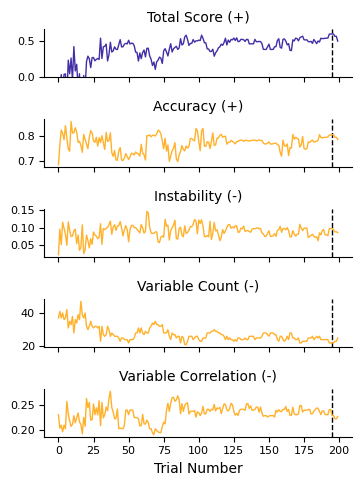

In [21]:
import seaborn as sns

## get the trial number with the best
best_trial = trial_data.trial_number[trial_data.objective_value.idxmax()]
# Long format: one row per (trial_number, metric_name, value)
metrics = {
    "objective_value": "Total Score (+)",
    "mean_auc": "Accuracy (+)",
    "std_auc": "Instability (-)",
    "n_features": "Variable Count (-)",
    "mean_abs_correlation": "Variable Correlation (-)",
}
long = trial_data.melt(
    id_vars=["trial_number"],
    value_vars=list(metrics.keys()),
    var_name="metric",
    value_name="value",
)
long["metric"] = long.metric.map(metrics)

g = sns.relplot(
    data=long,
    x="trial_number",
    y="value",
    row="metric",
    kind="line",
    height=1,
    aspect=4,
    facet_kws=dict(sharex=True, sharey=False),
    color="#ffb12b",
    linewidth=1,
)
for ax in g.axes.flat:
    ax.axvline(x=best_trial, color="black", linestyle="--", linewidth=1, zorder=0)


ax = g.axes_dict[metrics["objective_value"]]  # or whichever metric
ax.get_lines()[0].set_color("#422ea6")
ax.set_ylim(0)

for ax in g.axes.flat:
    ax.tick_params(axis="both", labelsize=8)

g.set_titles("{row_name}")

g.set_ylabels("")
g.set_xlabels("Trial Number")

In [22]:
import rasterio
import rioxarray as rxr

predictions_path = "data/sdm_predictions/all_predictions.tif"

with rasterio.open(predictions_path) as src:
    band_names = [d or f"band_{i}" for i, d in enumerate(src.descriptions)]

preds = rxr.open_rasterio(predictions_path)


preds = preds.where(preds != preds.attrs["_FillValue"])
preds = preds.assign_coords(band=band_names)
preds_ds = preds.to_dataset(dim="band")

# set nodata to nan
preds_ds


<xarray.Dataset> Size: 203MB
Dimensions:                              (y: 1544, x: 1930)
Coordinates:
  * x                                    (x) float64 15kB 3.562e+05 ... 5.492...
  * y                                    (y) float64 12kB 3.716e+05 ... 5.26e+05
    spatial_ref                          int64 8B 0
Data variables: (12/17)
    nyctalus_noctula_in_flight           (y, x) float32 12MB nan nan ... nan nan
    nyctalus_noctula_roost               (y, x) float32 12MB nan nan ... nan nan
    pipistrellus_pipistrellus_in_flight  (y, x) float32 12MB nan nan ... nan nan
    pipistrellus_pipistrellus_roost      (y, x) float32 12MB nan nan ... nan nan
    pipistrellus_pygmaeus_in_flight      (y, x) float32 12MB nan nan ... nan nan
    pipistrellus_pygmaeus_roost          (y, x) float32 12MB nan nan ... nan nan
    ...                                   ...
    myotis_nattereri_roost               (y, x) float32 12MB nan nan ... nan nan
    nyctalus_leisleri_in_flight          (y, x) float32 12MB nan nan ... nan nan
    nyctalus_leisleri_roost              (y, x) float32 12MB nan nan ... nan nan
    myotis_brandtii_roost                (y, x) float32 12MB nan nan ... nan nan
    myotis_mystacinus_in_flight          (y, x) float32 12MB nan nan ... nan nan
    myotis_mystacinus_roost              (y, x) float32 12MB nan nan ... nan nan
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     -9999.0
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('nyctalus_noctula_in_flight', 'nyctalus_noctula_roost', ...

In [23]:
# In-flight: keep vars ending with _in_flight, rename to species name
in_flight_vars = [v for v in preds_ds.data_vars if v.endswith("_in_flight")]
species_in_flight = [v.replace("_in_flight", "") for v in in_flight_vars]
preds_in_flight = preds_ds[in_flight_vars].rename(
    dict(zip(in_flight_vars, species_in_flight))
)

# Roosting: same idea for _roosting
roosting_vars = [v for v in preds_ds.data_vars if v.endswith("_roost")]
species_roosting = [v.replace("_roost", "") for v in roosting_vars]
preds_roosting = preds_ds[roosting_vars].rename(
    dict(zip(roosting_vars, species_roosting))
)

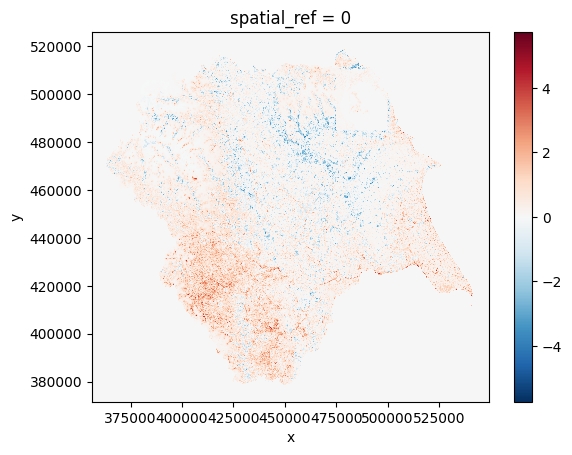

In [24]:
total_in_flight = preds_in_flight.to_array().sum(dim="variable")
total_roost = preds_roosting.to_array().sum(dim="variable")


(total_in_flight - total_roost).plot()

## SHAP: explain a specific point (from `sdm explain` artifacts)

Load saved explainer artifacts and plot SHAP values for a single (x, y) without re-running the expensive pipeline. Requires prior runs of `sdm train`, `sdm predict`, and `sdm explain`.

In [25]:
from pathlib import Path

from sdm.commands.modelling.explain_sdm_models import load_explainer_artifacts
from sdm.utils.text_utils import get_variable_display_name


def plot_point_shap(
    *,
    x: float,
    y: float,
    explainer,
    model_features,
    evs,
    n_top: int = 7,
    ax=None,
    positive_color: str = "#27949C",
    negative_color: str = "#DB5900",
    xlabel: str = "Influence Score (shap)",
):
    """
    Explain a single (x, y) point using a SHAP explainer and plot the top features.

    Parameters
    ----------
    x, y : float
        Coordinates in the same CRS as `evs`.
    explainer : shap.Explainer-like
        Explainer with .shap_values method.
    model_features : list[str]
        Feature names used by the model (column order must match training).
    evs : xr.Dataset
        Environmental variables dataset (with x, y dims).
    n_top : int, default 7
        Number of top absolute SHAP features to plot.
    ax : matplotlib.axes.Axes, optional
        Axes to plot onto. If None, a new figure/axes is created.
    positive_color, negative_color : str
        Colors for positive / negative SHAP values.
    xlabel : str
        X-axis label.

    Returns
    -------
    point_shap_df : pd.DataFrame
        Full SHAP scores for the point, sorted by shap_score descending.
    (fig, ax) : (matplotlib.figure.Figure, matplotlib.axes.Axes)
        Figure and axes used for the plot.
    """
    # Extract EVs for this point
    point_evs = evs.sel(x=[x], y=[y], method="nearest").to_dataframe()
    point_features = point_evs[model_features]

    # SHAP values for this point
    point_shap_values = explainer.shap_values(point_features)
    point_shap_df = pd.DataFrame(
        data={
            "variable": model_features,
            "input_value": point_features.values[0],
            "shap_score": point_shap_values[0],
        }
    ).sort_values(by="shap_score", ascending=False)

    # Prepare top-n for plotting
    df = (
        point_shap_df.sort_values("shap_score", key=abs, ascending=False)
        .head(n_top)
        .iloc[::-1]
    )
    df["label"] = df["variable"].apply(get_variable_display_name)

    colours = {"positive": positive_color, "negative": negative_color}

    # Create axes if needed
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 3.5))
        created_fig = True
    else:
        fig = ax.figure

    # Plot
    ax.barh(
        df["label"],
        df["shap_score"],
        color=[
            colours["positive"] if v >= 0 else colours["negative"]
            for v in df["shap_score"]
        ],
        height=0.65,
        alpha=0.7,
        edgecolor="black",
        linewidth=0.5,
    )
    ax.axvline(0, color="black", linewidth=0.6)
    ax.set_xlabel(xlabel)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=8)

    if created_fig:
        plt.tight_layout()
        plt.show()

    return point_shap_df, (fig, ax)


# Paths from sdm explain output (config.paths.predictions / visualization / shap / latin_name / activity_type)
shap_base = Path(config.paths.predictions) / "visualization" / "shap"
latin_name, activity_type = "Plecotus_auritus", "Roost"
artifacts_dir = (
    shap_base / latin_name.replace(" ", "_") / activity_type.replace(" ", "_")
)

artifacts = load_explainer_artifacts(artifacts_dir)
explainer = artifacts["explainer"]
model_features = artifacts["feature_names"]


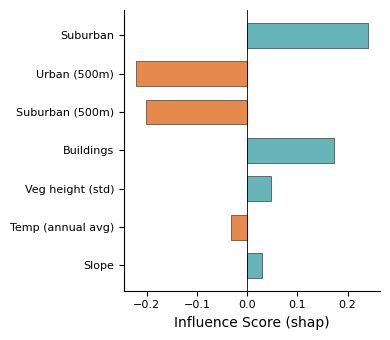

In [ ]:
x, y = 433303, 389717

df, fig = plot_point_shap(
    x=x, y=y, explainer=explainer, model_features=model_features, evs=evs
)


In [ ]:
from pathlib import Path

import seaborn as sns

from sdm.commands.modelling.explain_sdm_models import load_explainer_artifacts
from sdm.utils.text_utils import get_variable_display_name


def compute_point_shap_df(
    *,
    x: float,
    y: float,
    explainer,
    model_features,
    evs,
):
    """
    Return a DataFrame with columns:
    [variable, input_value, shap_score, label, direction]
    for a single (x, y) point.
    """
    # Extract EVs for this point
    point_evs = evs.sel(x=[x], y=[y], method="nearest").to_dataframe()
    point_features = point_evs[model_features]

    # SHAP values for this point
    point_shap_values = explainer.shap_values(point_features)

    df = pd.DataFrame(
        data={
            "variable": model_features,
            "input_value": point_features.values[0],
            "shap_score": point_shap_values[0],
        }
    )

    df["label"] = df["variable"].apply(get_variable_display_name)
    df["direction"] = df["shap_score"].apply(
        lambda v: "positive" if v >= 0 else "negative"
    )

    return df


def plot_point_shap_from_df(
    df,
    *,
    n_top: int = 7,
    ax=None,
    positive_color: str = "#27949C",
    negative_color: str = "#DB5900",
    xlabel: str = "Influence Score (shap)",
):
    """
    Plot top-n rows from a SHAP dataframe produced by compute_point_shap_df.
    Returns (df_top, (fig, ax))
    """
    # Select top-n by absolute shap_score and flip so largest at top
    df_top = (
        df.sort_values("shap_score", key=abs, ascending=False)
        .head(n_top)
        .iloc[::-1]
        .reset_index(drop=True)
    )

    palette = {"positive": positive_color, "negative": negative_color}

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 3.5))
        created_fig = True
    else:
        fig = ax.figure

    sns.barplot(
        data=df_top,
        x="shap_score",
        y="label",
        hue="direction",
        dodge=False,
        palette=palette,
        errorbar=None,
        ax=ax,
        orient="h",
    )

    ax.axvline(0, color="black", linewidth=0.6)
    ax.set_xlabel(xlabel)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=8)
    ax.legend_.remove()
    ax.set_ylabel("")

    if created_fig:
        plt.tight_layout()
        plt.show()

    return df_top, (fig, ax)


# Paths from sdm explain output (config.paths.predictions / visualization / shap / latin_name / activity_type)
shap_base = Path(config.paths.predictions) / "visualization" / "shap"
latin_name, activity_type = "Plecotus_auritus", "Roost"
artifacts_dir = (
    shap_base / latin_name.replace(" ", "_") / activity_type.replace(" ", "_")
)

artifacts = load_explainer_artifacts(artifacts_dir)
explainer = artifacts["explainer"]
model_features = artifacts["feature_names"]

preds_ds_variable_name = (
    latin_name.lower().replace(" ", "_") + "_" + activity_type.lower().replace(" ", "_")
)

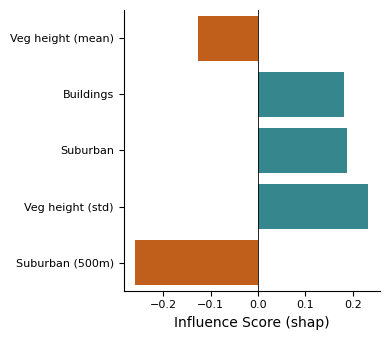

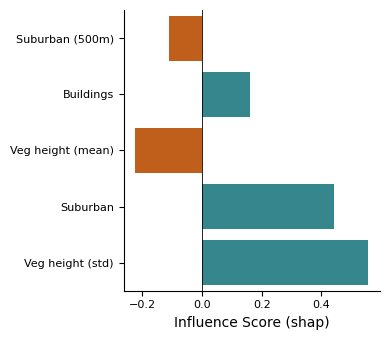

In [45]:
# Point to explain (same CRS as evs, e.g. British National Grid)
x1, y1 = 431056.1, 392855.1
x2, y2 = 431140.9, 392647.6

df1 = compute_point_shap_df(
    x=x1, y=y1, explainer=explainer, model_features=model_features, evs=evs
)
df2 = compute_point_shap_df(
    x=x2, y=y2, explainer=explainer, model_features=model_features, evs=evs
)


# Option B: select the same variables across both
common_vars = set(
    df1.sort_values("shap_score", key=abs, ascending=False).head(10)["variable"]
) & set(df2.sort_values("shap_score", key=abs, ascending=False).head(10)["variable"])

df1_common = df1[df1["variable"].isin(common_vars)]
df2_common = df2[df2["variable"].isin(common_vars)]


df1_top, (fig1, ax1) = plot_point_shap_from_df(df1_common, n_top=5)
df2_top, (fig2, ax2) = plot_point_shap_from_df(df2_common, n_top=5)

for ax in (ax1, ax2):
    ax.set_xlim(-0.5, 0.5)


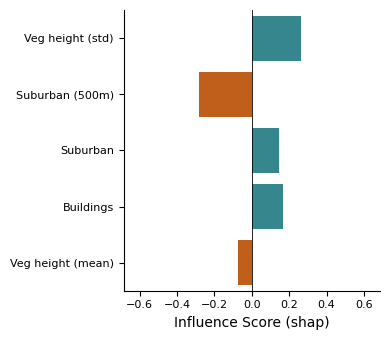

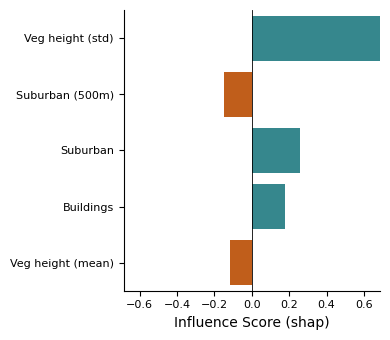

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sdm.commands.modelling.explain_sdm_models import load_explainer_artifacts
from sdm.utils.text_utils import get_variable_display_name


def compute_point_shap_df(
    *,
    x: float,
    y: float,
    explainer,
    model_features,
    evs,
):
    """
    Return a DataFrame with columns:
    [variable, input_value, shap_score, label, direction]
    for a single (x, y) point.
    """
    # Extract EVs for this point
    point_evs = evs.sel(x=[x], y=[y], method="nearest").to_dataframe()
    point_features = point_evs[model_features]

    # SHAP values for this point
    point_shap_values = explainer.shap_values(point_features)

    df = pd.DataFrame(
        data={
            "variable": model_features,
            "input_value": point_features.values[0],
            "shap_score": point_shap_values[0],
        }
    )

    df["label"] = df["variable"].apply(get_variable_display_name)
    df["direction"] = df["shap_score"].apply(
        lambda v: "positive" if v >= 0 else "negative"
    )

    return df


def plot_point_shap_from_df(
    df,
    *,
    ax=None,
    positive_color: str = "#27949C",
    negative_color: str = "#DB5900",
    xlabel: str = "Influence Score (shap)",
):
    """
    Plot a SHAP dataframe produced by compute_point_shap_df.
    Assumes df['label'] is an ordered Categorical to control y-axis order.
    Returns (df, (fig, ax))
    """
    palette = {"positive": positive_color, "negative": negative_color}

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 3.5))
        created_fig = True
    else:
        fig = ax.figure

    sns.barplot(
        data=df,
        x="shap_score",
        y="label",
        hue="direction",
        dodge=False,
        palette=palette,
        errorbar=None,
        ax=ax,
        orient="h",
    )

    ax.axvline(0, color="black", linewidth=0.6)
    ax.set_xlabel(xlabel)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=8)
    ax.legend_.remove()
    ax.set_ylabel("")

    return df, (fig, ax)


# -------------------------------------------------
# Load explainer artifacts for Plecotus auritus - Roost
# -------------------------------------------------
shap_base = Path(config.paths.predictions) / "visualization" / "shap"
latin_name, activity_type = "Plecotus_auritus", "Roost"
artifacts_dir = (
    shap_base / latin_name.replace(" ", "_") / activity_type.replace(" ", "_")
)

artifacts = load_explainer_artifacts(artifacts_dir)
explainer = artifacts["explainer"]
model_features = artifacts["feature_names"]

preds_ds_variable_name = (
    latin_name.lower().replace(" ", "_") + "_" + activity_type.lower().replace(" ", "_")
)

# -------------------------------------------------
# Two points, same vars/order/limits, separate figs
# -------------------------------------------------

# Points to explain (same CRS as evs)
x1, y1 = 431037.2, 392845.4
x2, y2 = 431151.6, 392639.5

df1 = compute_point_shap_df(
    x=x1, y=y1, explainer=explainer, model_features=model_features, evs=evs
)
df2 = compute_point_shap_df(
    x=x2, y=y2, explainer=explainer, model_features=model_features, evs=evs
)

k = 5  # “top k” to drive which vars appear

# Top-k variables per point by |shap|
top1 = df1.sort_values("shap_score", key=abs, ascending=False).head(k)["variable"]
top2 = df2.sort_values("shap_score", key=abs, ascending=False).head(k)["variable"]

# Union of top-k variables across both
var_set = set(top1) | set(top2)

df1_sub = df1[df1["variable"].isin(var_set)].copy()
df2_sub = df2[df2["variable"].isin(var_set)].copy()

# Define a single shared variable order (top→bottom) using combined |shap|
combined = (
    pd.concat(
        [
            df1_sub[["variable", "shap_score"]],
            df2_sub[["variable", "shap_score"]],
        ]
    )
    .assign(abs_shap=lambda d: d["shap_score"].abs())
    .groupby("variable", as_index=False)["abs_shap"]
    .sum()
    .sort_values("abs_shap", ascending=False)
)

var_order = combined["variable"].tolist()
label_order = [get_variable_display_name(v) for v in var_order]

df1_sub["label"] = pd.Categorical(
    df1_sub["label"], categories=label_order, ordered=True
)
df2_sub["label"] = pd.Categorical(
    df2_sub["label"], categories=label_order, ordered=True
)

# Shared symmetric x-limits
max_abs = max(
    df1_sub["shap_score"].abs().max(),
    df2_sub["shap_score"].abs().max(),
)
xlim = (-max_abs, max_abs)

# ----- Independent figure for point 1 -----
df1_plot, (fig1, ax1) = plot_point_shap_from_df(df1_sub, ax=None)
ax1.set_xlim(xlim)

fig1.tight_layout()
# fig1.savefig("plecotus_roost_point1.png", dpi=300)

# ----- Independent figure for point 2 -----
df2_plot, (fig2, ax2) = plot_point_shap_from_df(df2_sub, ax=None)
ax2.set_xlim(xlim)

fig2.tight_layout()
# fig2.savefig("plecotus_roost_point2.png", dpi=300)